In [122]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader

In [149]:
from tavily import TavilyClient

In [ ]:
tavily_client = TavilyClient()

response = tavily_client.search("Latest AI research trends 2026")
print(response)

{'query': 'Latest AI research trends 2026', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.abiresearch.com/blog/top-ai-trends', 'title': "ABI Research's Top 7 AI Trends to Watch in 2026", 'content': '1. On-device AI in smartphones will face a reality check · 2. Neoclouds will struggle to unlock enterprise AI at scale · 3. Physical AI will', 'score': 0.9168945, 'raw_content': None}, {'url': 'https://sloanreview.mit.edu/article/five-trends-in-ai-and-data-science-for-2026/', 'title': 'Five Trends in AI and Data Science for 2026', 'content': "1. The AI bubble will deflate, and the economy will suffer. · 2. More all-in adopters will create 'AI factories' and infrastructure. · 3. · 4.", 'score': 0.885404, 'raw_content': None}, {'url': 'https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/', 'title': "What's next in AI: 7 trends to watch in 2026 - Microsoft Source", 'content': 'Seven AI trends to watch in 2026 wi

In [123]:
class GraphState(TypedDict):
    syllabus: str
    has_book: bool

    topics: List[str]
    current_topic_index: int
    current_topic: str

    research_content: str
    draft_notes: str

    critic_feedback: str
    critic_pass: bool
    retry_count: int

    final_notes: str
    exam_questions: str

    all_notes: List[str]
    all_questions: List[str]

    final_document: str

In [124]:
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [125]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.3
)

## Prompt

In [ ]:
planner_prompt= ChatPromptTemplate.from_messages([
    ("system","""
    You are an academic planner.

    Task:
    Given a syllabus, break it into structured topics.

    Rules:
    - Create logical, well defined topics(not too broad, not too granular)
    - Maintain prerequisite order
    - Each topic must be independently understandable
    - Avoid redudancy
    

    Output format:
    Return only a numbered list of topics
    DO NOT INCLUDE EXPLANATION

    - ONLY use topics explicitly present in syllabus
    - DO NOT add extra topics
    - DO NOT generalize


    """),
    ("human","{syllabus}")
])


researcher_prompt= ChatPromptTemplate.from_messages([
    ("system","""
    You are a research assistant.

    Task:
    Collect accurate and relevant information for the given topic.


    Rules:
    - Focus only on factual content
    - Include defintion, key concepts, important detials and examples if required
    - DO NOT explain in teaching style
    - DO NOT Format as notes
    - Keep content concise but complete
    - Avoid repetition

    Output:
    Return raw, factual content only.
    """
    ),
    ("human","Topic:{topic}\nContext:{context}")
])


writer_prompt= ChatPromptTemplate.from_messages([
    ("system","""
    You are an expert professor creatin exam-ready notes.

    Task:
    Convert the given content into structured notes.

    Rules:
    - Keep explanation clear, concise, and exam-oriented
    - Avoid unnecessary fluffy
    - Maintain logical flow

    Strict Format:
    1. Definition
    2. Intution (simple language explanation)
    3. Detailed Expalantion
    4. Example(real world ir conceptual)
    5. Key Points (bullet points)
    6. OPTIONAL IF NEEDED Code snippet with sample INPUT and OUTPUT
    

    OUTPUT MUST FOLLOW THIS STRUCUTRE EXACTLY.
    """),
    ("human","Topic:{topic}\nContent:{research_content}")
])

critic_prompt= ChatPromptTemplate.from_messages([
    ("system","""
    You are a strict academic reviewer.

    Task:
    Evaluate the given notes

    Check:
    1. Is the defintion precise and correct?
    2. Is the explanation complete?
    3. Is the content exam-oriented?
    4. Is there a clear example?
    5. any vague or incorrect statements

    Output format:
    - PASS or FAIL
    - If Fail,provide specific improvement instructions
    - Keep feedback actionable and precise


    If ANY improvement needed → return FAIL
    PASS only if perfect and exam-ready
    Be Strict like university examiner
    """),
("human","Topic:{topic}\nNotes:{draft_notes}")
])

exam_prompt= ChatPromptTemplate.from_messages(
    [
        ("system","""
        You are an exam paper setter

        Task:
        Generate important questions based on the topic and notes.

        Rules:
        - Focus on frequently asked concepts
        - Cover both theory and application

        Generate:
        - 2:2 mark questions
        - 2: 5 mark questions
        - if it is really important and cannt skipped 1: 10 mark question

        OUTPUT CLEARLY GROUPED BY MARKS
        """),
        ("human","Topic:{topic}\nNotes:{final_notes}")
    ]
)

## NODES

In [ ]:
def planner_node(state:GraphState):
    response= llm.invoke(
        planner_prompt.format_messages(syllabus=state["syllabus"])
    )

    topics = [
        t.strip("0123456789. -")
        for t in response.content.split("\n")
        if t.strip()
    ]
    if not topics:
        raise ValueError("No topics generated")
    return {
        **state,
        "topics":topics,
        "current_topic_index":0,
        "current_topic":topics[0]
    }


def researcher_node(state:GraphState):
    topic =state["current_topic"]
    has_book=state["has_book"]

    context=""

    query_prompt = f"""
        Generate 3 highly specific search queries for:
        {topic}

        Each query must:
        - explicitly include the topic name
        - target definition, working, and components
        - avoid generic terms

        Return only list.
        """

    queries_resp=llm.invoke(query_prompt)
    queries = [
    q.strip("- ").strip()
    for q in queries_resp.content.split("\n")
    if q.strip()
]

    docs=[]

    if has_book:
        for q in queries:
            results= vectorstore.similarity_search(q,k=3)
            docs.extend(results)

        seen= set()
        filtered_docs=[]
        for d in docs:
            if d.page_content not in seen:
                seen.add(d.page_content)
                filtered_docs.append(d)

        context="\n\n".join([d.page_content for d in filtered_docs[:8]])

    else:
        results= tavily_client.search(query=topic)
        context = "\n\n".join([
            r["content"] for r in results["results"]
        ])

    context = context[:3000]

    response = llm.invoke(
        researcher_prompt.format_messages(
            topic=topic,
            context=context
        )
    )

    return {
        **state,
        "research_content": response.content
    }



def writer_node(state:GraphState):
    feedback=state.get("critic_feedback","")
    content=state["research_content"]

    if feedback:
        content += f"\n\nSTRICTLY FIX THESE ISSUES:\n{feedback}"

    response= llm.invoke(
        writer_prompt.format_messages(
            topic=state["current_topic"],
            research_content=content
        )
    )

    return {
        **state,
        "draft_notes":response.content
    }


def critic_node(state:GraphState):
    response=llm.invoke(
        critic_prompt.format_messages(
            topic=state["current_topic"],
            draft_notes= state["draft_notes"]
        )
    )

    output=response.content.lower()

    pass_fail = output.strip().startswith("pass")
    retry_count=state.get("retry_count",0)

    if not pass_fail:
        retry_count+=1

    return {
        **state,
        "critic_pass":pass_fail,
        "critic_feedback":response.content,
        "retry_count":retry_count
    }


def exam_agent_node(state: GraphState):
    response = llm.invoke(
        exam_prompt.format_messages(
            topic=state["current_topic"],
            final_notes=state["draft_notes"]
        )
    )

    return {
        **state,
        "final_notes": state["draft_notes"],
        "exam_questions": response.content,
        "all_notes": state.get("all_notes", []) + [state["draft_notes"]],
        "all_questions": state.get("all_questions", []) + [response.content]
    }


def next_topic_node(state: GraphState):
    next_index = state["current_topic_index"] + 1

    return {
        **state,
        "current_topic_index": next_index,
        "current_topic": state["topics"][next_index],
        "retry_count": 0,
        "critic_feedback": "",
        "critic_pass": False
    }

def formatter_node(state: GraphState):
    combined = ""

    for i, topic in enumerate(state["topics"]):
        combined += f"# {topic}\n\n"
        combined += state["all_notes"][i] + "\n\n"
        combined += "## Important Questions\n"
        combined += state["all_questions"][i] + "\n\n"

    return {
        **state,
        "final_document": combined
    }

# ROUTER

In [128]:
def critic_router(state: GraphState):
    if state["critic_pass"] or state["retry_count"] >= 3:
        return "exam_agent"
    else:
        return "writer"

def topic_router(state: GraphState):
    if state["current_topic_index"] + 1 < len(state["topics"]):
        return "next_topic"
    else:
        return "formatter"

# Graph

In [129]:
builder=StateGraph(GraphState)

builder.add_node("planner",planner_node)
builder.add_node("researcher",researcher_node)
builder.add_node("writer",writer_node)
builder.add_node("critic",critic_node)
builder.add_node("exam_agent",exam_agent_node)
builder.add_node("next_topic",next_topic_node)
builder.add_node("formatter",formatter_node)


# EDGES
builder.set_entry_point("planner")

builder.add_edge("planner","researcher")
builder.add_edge("researcher","writer")
builder.add_edge("writer","critic")


builder.add_conditional_edges(
    "critic",
    critic_router,
    {
        "writer":"writer",
        "exam_agent":"exam_agent"
    }
)

builder.add_conditional_edges(
    "exam_agent",
    topic_router,
    {
        "next_topic": "next_topic",
        "formatter": "formatter"
    }
)

builder.add_edge("next_topic","researcher")
builder.add_edge("formatter",END)

In [130]:
graph = builder.compile()

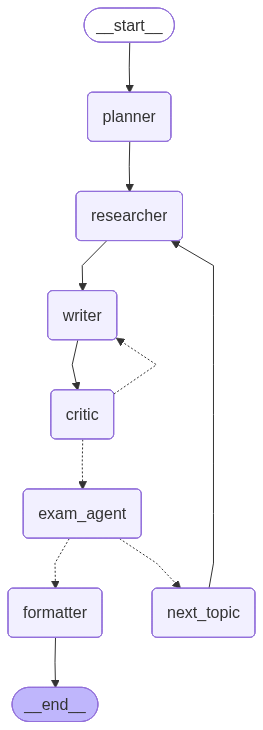

In [131]:
graph

## TESTING

In [132]:
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("fun.pdf")
documents = loader.load()

In [133]:
documents

[Document(metadata={'producer': 'Adobe Acrobat 8.0', 'creator': 'Adobe Acrobat 8.0 Combine Files', 'creationdate': '2017-08-21T13:04:43+05:30', 'source': 'fun.pdf', 'file_path': 'fun.pdf', 'total_pages': 256, 'format': 'PDF 1.6', 'title': 'prelim.pmd', 'author': 'abc', 'subject': '', 'keywords': '', 'moddate': '2017-08-21T13:04:43+05:30', 'trapped': '', 'modDate': "D:20170821130443+05'30'", 'creationDate': "D:20170821130443+05'30'", 'page': 0}, page_content='Fundamentals of Soft Computing\nBy\nKuntal Barua\nAssistant Professor, Department of Computer Science and Engineering\nSANGAM UNIVERSITY, Bhilwara.\nProf Dr Prasun Chakrabarti\nProfessor and Head-Department of Computer Science and Engineering\nSir Padampat Singhania University, Udaipur.\nBPB PUBLICATIONS\n20 Ansari Road, Darya Ganj New Delhi-110002'),
 Document(metadata={'producer': 'Adobe Acrobat 8.0', 'creator': 'Adobe Acrobat 8.0 Combine Files', 'creationdate': '2017-08-21T13:04:43+05:30', 'source': 'fun.pdf', 'file_path': 'fun.

In [134]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=80
)

docs = splitter.split_documents(documents)

In [136]:
docs

[Document(metadata={'producer': 'Adobe Acrobat 8.0', 'creator': 'Adobe Acrobat 8.0 Combine Files', 'creationdate': '2017-08-21T13:04:43+05:30', 'source': 'fun.pdf', 'file_path': 'fun.pdf', 'total_pages': 256, 'format': 'PDF 1.6', 'title': 'prelim.pmd', 'author': 'abc', 'subject': '', 'keywords': '', 'moddate': '2017-08-21T13:04:43+05:30', 'trapped': '', 'modDate': "D:20170821130443+05'30'", 'creationDate': "D:20170821130443+05'30'", 'page': 0}, page_content='Fundamentals of Soft Computing\nBy\nKuntal Barua\nAssistant Professor, Department of Computer Science and Engineering\nSANGAM UNIVERSITY, Bhilwara.\nProf Dr Prasun Chakrabarti\nProfessor and Head-Department of Computer Science and Engineering\nSir Padampat Singhania University, Udaipur.\nBPB PUBLICATIONS\n20 Ansari Road, Darya Ganj New Delhi-110002'),
 Document(metadata={'producer': 'Adobe Acrobat 8.0', 'creator': 'Adobe Acrobat 8.0 Combine Files', 'creationdate': '2017-08-21T13:04:43+05:30', 'source': 'fun.pdf', 'file_path': 'fun.

In [137]:

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2118.76it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [138]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(docs, embeddings)

In [139]:
# planner_node({
#     "syllabus": """Introduction to Fuzzy logic controller: Architecture, Fuzzification, Membership functions: Triangular, Trapezoidal, Gaussian. 
# Inference Mechanism, knowledge base, fuzzy rule base, Inference method: Mamdani, Sugeno and TSK models, Defuzzification, 
# Applications of Fuzzy logic controller."""
# })

In [140]:
# state = {
#     "current_topic": "Fuzzy Rule Base",
#     "has_book": True
# }

In [141]:
# researcher_node(state)

In [142]:
# writer_node({
#     "current_topic": "Fuzzy Rule Base",
#     "research_content": researcher_node(state)['research_content'],
#     "critic_feedback": ""
# })

In [143]:
# critic_node({
#     "current_topic": "...",
#     "draft_notes": "..."
# })

In [151]:
result = graph.invoke({
    "syllabus": """
    Fuzzy Rule Base,
    Defuzzification
    """,
    "has_book": False,
    "topics": [],
    "current_topic_index": 0,
    "all_notes": [],
    "all_questions": [],
    "retry_count": 0,
    "critic_feedback": "",
    "critic_pass": False,
    "research_content": "",
    "draft_notes": "",
    "final_notes": "",
    "exam_questions": "",
    "final_document": ""
})

In [152]:
result

{'syllabus': '\n    Fuzzy Rule Base,\n    Defuzzification\n    ',
 'has_book': False,
 'topics': ['Fuzzy Sets',
  'Fuzzy Relations',
  'Fuzzy Rule Base',
  'Fuzzy Inference Systems',
  'Defuzzification',
  'Membership Functions',
  'Fuzzy Logic Operators'],
 'current_topic_index': 6,
 'current_topic': 'Fuzzy Logic Operators',
 'research_content': 'Fuzzy logic operators are used to combine membership values of input variables to make decisions in fuzzy systems. The main fuzzy logic operators are:\n\n1. **AND (Conjunction)**: Also known as the minimum operator (MIN), it calculates the minimum membership value between two inputs. This operator is used to combine two conditions that must both be true for the rule to be satisfied.\n\n2. **OR (Disjunction)**: Also known as the maximum operator (MAX), it calculates the maximum membership value between two inputs. This operator is used to combine two conditions where at least one of them must be true for the rule to be satisfied.\n\n3. **NOT (

In [153]:
print(result['final_notes'])

**Fuzzy Logic Operators**

### Definition

Fuzzy logic operators are mathematical functions used to combine membership values of input variables in fuzzy systems to enable decision-making by aggregating the degree of truth or membership of input variables. They are used to make decisions in fuzzy systems by combining the membership values of input variables.

### Intuition

Fuzzy logic operators are used to combine membership values of input variables to make decisions in fuzzy systems. They allow for gradual and continuous transitions between different states, avoiding ambiguity problems.

### Detailed Explanation

Fuzzy logic operators are used to combine membership values of input variables in fuzzy systems. The main fuzzy logic operators are:

1. **AND (Conjunction)**: Also known as the minimum operator (MIN), it calculates the minimum membership value between two inputs. This operator is used to combine two conditions that must both be true for the rule to be satisfied.
2. **OR (D

## WITH BOOK

In [ ]:
result

{'syllabus': '\n    Fuzzy Rule Base,\n    Defuzzification\n    ',
 'has_book': True,
 'topics': ['Fuzzy Rule Base', 'Defuzzification'],
 'current_topic_index': 1,
 'current_topic': 'Defuzzification',
 'research_content': 'Defuzzification is a process in fuzzy logic control (FLC) that translates the output of a fuzzy inference system (FIS) into a crisp, numerical value. It is an essential step in FLC, as it enables the system to produce a real control action from the fuzzy control action obtained through the inference process.\n\nThere are several defuzzification methods, but two popular techniques are:\n\n1. **Center of Mass (COM)**: This method calculates the center of mass of the output distribution, which is obtained by multiplying the membership values of each output by their corresponding values and summing them up. The formula for COM is:\n\n∑∑= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

In [147]:
print(result['final_notes'])

**Defuzzification**

**Definition**: Defuzzification is a process that converts a fuzzy set into a crisp value by selecting a representative value from the fuzzy set. It is a crucial step in Fuzzy Logic Control (FLC), enabling the system to produce a real control action from the fuzzy control action obtained through the inference process.

**Intuition**: Imagine you're controlling a thermostat in a room. The Fuzzy Inference System (FIS) takes in temperature readings and outputs a fuzzy control action, such as "cool," "warm," or "just right." Defuzzification takes this fuzzy output and converts it into a specific temperature value, like 22°C, that the thermostat can use to adjust the temperature.

**Detailed Explanation**: Defuzzification is a process that involves selecting a representative value from the output distribution of the FIS. There are several defuzzification methods, including:

* **Center of Mass (COM)**: This method calculates the center of mass of the output distribution